In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

# load the olivetti faces dataset
data = fetch_olivetti_faces()
X = data.data  # Flattened images
y = data.target  # Labels (person IDs)

In [3]:
# shuffle the training data
shuffle_indices = np.random.permutation(len(X))
X = X[shuffle_indices]
y = y[shuffle_indices]

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(320, 4096) (80, 4096)


In [4]:
# normalize the data to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

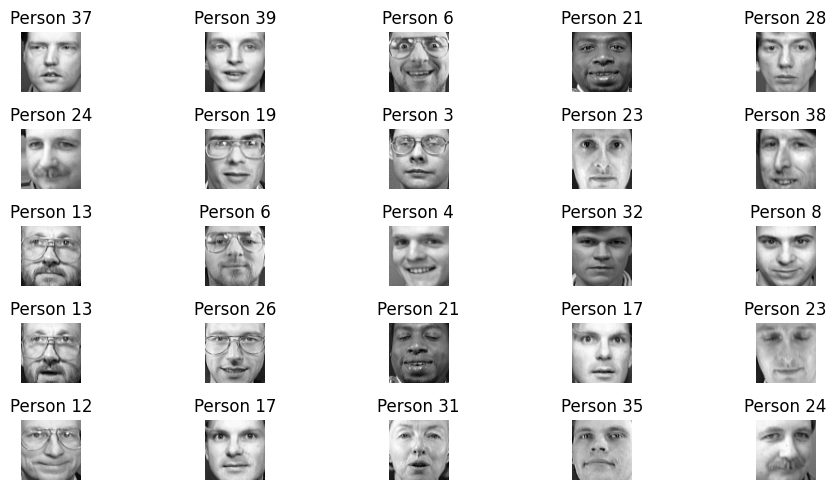

In [5]:
# visualize some sample images from the dataset
fig, axes = plt.subplots(5, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Person {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
class FuzzyART:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5, learning_rate: float = 1.0, alpha: float = 0.001, complement: bool = True):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features * 2 if complement else num_features
        # β is a small positive constant (often β < 1)
        self.beta = learning_rate
        # α is a small positive constant used in the choice function.
        self.alpha = alpha
        # for each feature xi​, its complement (1−xi)​ is also included in the input vector
        self.complement = complement
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        # self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.weights = np.ones((self.max_clusters, self.num_features))

    def _complement_code(self, X: np.ndarray) -> np.ndarray:
        return np.concatenate([X, 1 - X])

    def _fuzzy_and(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        return np.minimum(X, W)

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # Tj = ‖x ∧ Wj‖ / α + ‖Wj‖
        for j in range(self.num_clusters):
            activations[j] = np.sum(self._fuzzy_and(X, self.weights[j])) / (self.alpha + np.sum(self.weights[j]))
            print(f"Cluster {j}: activation={activations[j]:.4f}")
        
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # ‖x ∧ Wj‖ / ‖x‖ ≥ ρ
        fuzzy_and_norm = np.sum(self._fuzzy_and(X, self.weights[best_cluster]))
        if fuzzy_and_norm == 0:
            return False
        match_ratio = fuzzy_and_norm / np.sum(X)
        print(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}")
        with open ("vigilance_log.txt", "a") as log_file:
            log_file.write(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}\n")
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # wJ (new) = β(x ∧ wJ (old)) + (1 − β)wJ (old)
        new_wj = self.beta * self._fuzzy_and(X, self.weights[cluster_idx]) + (1 - self.beta) * self.weights[cluster_idx]
        self.weights[cluster_idx] = new_wj

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X

        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))
                with open ("f2_activation_log.txt", "a") as log_file:
                    log_file.write(f"Best cluster selected: {best_cluster} with activation {f2_activations[best_cluster]:.4f}\n")

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached. "
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            # self._update_weights(X, new_idx)
            self.weights[new_idx] = X.copy()
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return sorted_clusters[0]

In [9]:
net = FuzzyART(
    num_features=X_train.shape[1],
    max_clusters=4000,
    vigilance=0.9995,
    learning_rate=0.6,
    alpha=0.01,
    complement=True
 )

cluster_assignments = np.full(len(X_train), -1, dtype=np.int32)
for i, x in enumerate(X_train):
    print(f"Training sample {i+1}/{len(X_train)}", end="\r")
    try:
        cluster_assignments[i] = net.train(x)
    except RuntimeError:
        cluster_assignments = cluster_assignments[:i]
        print(f"Stopped at sample {i}")
        break

print(f"Active clusters: {net.num_clusters}")
print(f"Trained samples: {len(cluster_assignments)}")

Cluster 0: activation=0.9990
Cluster 0: match_ratio=0.9990, vigilance=0.9995
Cluster 0: activation=0.9994
Cluster 1: activation=0.9992
Cluster 0: match_ratio=0.9994, vigilance=0.9995
Cluster 0: activation=0.9992
Cluster 1: activation=0.9995
Cluster 2: activation=0.9994
Cluster 1: match_ratio=0.9995, vigilance=0.9995
Cluster 0: activation=0.9992
Cluster 1: activation=0.9995
Cluster 2: activation=0.9993
Cluster 3: activation=0.9995
Cluster 3: match_ratio=0.9995, vigilance=0.9995
Cluster 0: activation=0.9994
Cluster 1: activation=0.9994
Cluster 2: activation=0.9995
Cluster 3: activation=0.9996
Cluster 3: match_ratio=0.9993, vigilance=0.9995
Cluster 0: activation=0.9996
Cluster 1: activation=0.9990
Cluster 2: activation=0.9994
Cluster 3: activation=0.9994
Cluster 4: activation=0.9994
Cluster 0: match_ratio=0.9996, vigilance=0.9995
Cluster 0: activation=0.9996
Cluster 1: activation=0.9991
Cluster 2: activation=0.9994
Cluster 3: activation=0.9994
Cluster 4: activation=0.9994
Cluster 0: match

Total clusters found: 1


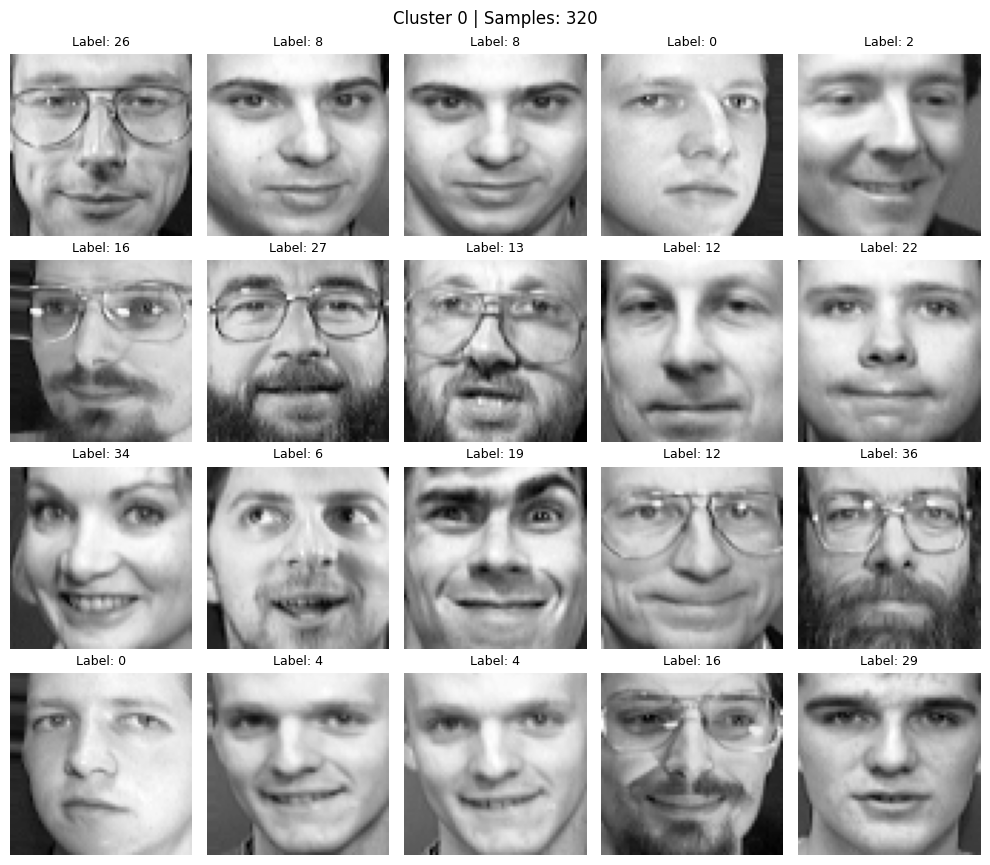

In [8]:
# Show image samples for each ART1 cluster
trained_n = len(cluster_assignments)
X_trained = X_train[:trained_n]
y_trained = y_train[:trained_n]

samples_per_cluster = 20
cluster_ids = np.unique(cluster_assignments)

print(f"Total clusters found: {len(cluster_ids)}")

for cluster_id in cluster_ids[:10]:
    idx = np.where(cluster_assignments == cluster_id)[0]
    if len(idx) == 0:
        continue

    # Pick up to N samples from this cluster (randomized for variety)
    n_show = min(samples_per_cluster, len(idx))
    show_idx = np.random.choice(idx, size=n_show, replace=False)

    cols = 5
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax, sample_i in zip(axes, show_idx):
        ax.imshow(X_trained[sample_i].reshape(64, 64), cmap="gray")
        label_text = y_trained[sample_i]
        ax.set_title(f"Label: {label_text}", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.suptitle(f"Cluster {cluster_id} | Samples: {len(idx)}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [11]:
from collections import Counter

y_trained = y_train[:trained_n]

purities = []
cluster_label_map = {}

print("\nCluster purity analysis:")
for cid in cluster_ids:
    idx = np.where(cluster_assignments == cid)[0]
    label_counts = Counter(y_trained[idx])
    dominant = label_counts.most_common(1)[0]
    cluster_label_map[cid] = dominant[0]
    purity = dominant[1] / len(idx)
    purities.append(purity)
    print(f"Cluster {cid:2d}: {len(idx):5d} samples | dominant digit={dominant[0]} | purity={purity:.1%}")

# ponder overall accuracy by cluster size
weights = np.array([len(np.where(cluster_assignments == cid)[0]) for cid in cluster_ids])
accuracy = np.average(purities, weights=weights)
print(f"Overall accuracy: {accuracy:.1%}")


Cluster purity analysis:
Cluster  0:     3 samples | dominant digit=15 | purity=66.7%
Cluster  1:     7 samples | dominant digit=26 | purity=100.0%
Cluster  2:     4 samples | dominant digit=20 | purity=50.0%
Cluster  3:     8 samples | dominant digit=21 | purity=100.0%
Cluster  4:     4 samples | dominant digit=24 | purity=100.0%
Cluster  5:     1 samples | dominant digit=37 | purity=100.0%
Cluster  6:     2 samples | dominant digit=7 | purity=100.0%
Cluster  7:     1 samples | dominant digit=28 | purity=100.0%
Cluster  8:     5 samples | dominant digit=13 | purity=100.0%
Cluster  9:     5 samples | dominant digit=17 | purity=80.0%
Cluster 10:     6 samples | dominant digit=33 | purity=100.0%
Cluster 11:     1 samples | dominant digit=9 | purity=100.0%
Cluster 12:     3 samples | dominant digit=30 | purity=100.0%
Cluster 13:     1 samples | dominant digit=24 | purity=100.0%
Cluster 14:     5 samples | dominant digit=36 | purity=100.0%
Cluster 15:     1 samples | dominant digit=2 | pu

Cluster 0: activation=0.9997
Cluster 1: activation=0.9997
Cluster 2: activation=0.9996
Cluster 3: activation=0.9992
Cluster 4: activation=0.9996
Cluster 5: activation=0.9994
Cluster 6: activation=0.9995
Cluster 7: activation=0.9991
Cluster 8: activation=0.9996
Cluster 9: activation=0.9998
Cluster 10: activation=0.9993
Cluster 11: activation=0.9994
Cluster 12: activation=0.9994
Cluster 13: activation=0.9995
Cluster 14: activation=0.9993
Cluster 15: activation=0.9995
Cluster 16: activation=0.9997
Cluster 17: activation=0.9995
Cluster 18: activation=0.9994
Cluster 19: activation=0.9994
Cluster 20: activation=0.9995
Cluster 21: activation=0.9996
Cluster 22: activation=0.9995
Cluster 23: activation=0.9992
Cluster 24: activation=0.9994
Cluster 25: activation=0.9993
Cluster 26: activation=0.9992
Cluster 27: activation=0.9995
Cluster 28: activation=0.9994
Cluster 29: activation=0.9994
Cluster 30: activation=0.9995
Cluster 31: activation=0.9994
Cluster 32: activation=0.9995
Cluster 33: activati

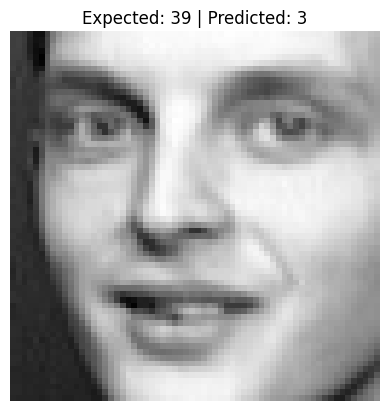

Cluster 0: activation=0.9992
Cluster 1: activation=0.9995
Cluster 2: activation=0.9996
Cluster 3: activation=0.9998
Cluster 4: activation=0.9993
Cluster 5: activation=0.9992
Cluster 6: activation=0.9990
Cluster 7: activation=0.9997
Cluster 8: activation=0.9995
Cluster 9: activation=0.9992
Cluster 10: activation=0.9997
Cluster 11: activation=0.9992
Cluster 12: activation=0.9995
Cluster 13: activation=0.9992
Cluster 14: activation=0.9996
Cluster 15: activation=0.9991
Cluster 16: activation=0.9992
Cluster 17: activation=0.9993
Cluster 18: activation=0.9995
Cluster 19: activation=0.9991
Cluster 20: activation=0.9996
Cluster 21: activation=0.9992
Cluster 22: activation=0.9991
Cluster 23: activation=0.9995
Cluster 24: activation=0.9993
Cluster 25: activation=0.9993
Cluster 26: activation=0.9997
Cluster 27: activation=0.9993
Cluster 28: activation=0.9990
Cluster 29: activation=0.9992
Cluster 30: activation=0.9992
Cluster 31: activation=0.9990
Cluster 32: activation=0.9991
Cluster 33: activati

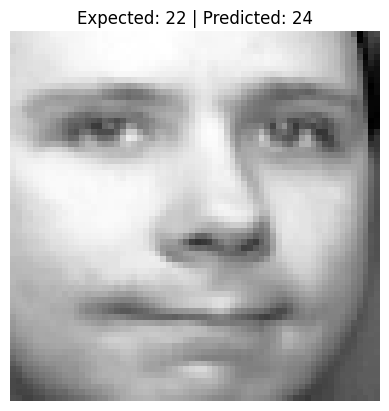

Cluster 0: activation=0.9997
Cluster 1: activation=0.9998
Cluster 2: activation=0.9997
Cluster 3: activation=0.9995
Cluster 4: activation=0.9997
Cluster 5: activation=0.9995
Cluster 6: activation=0.9994
Cluster 7: activation=0.9994
Cluster 8: activation=0.9998
Cluster 9: activation=0.9996
Cluster 10: activation=0.9995
Cluster 11: activation=0.9995
Cluster 12: activation=0.9995
Cluster 13: activation=0.9995
Cluster 14: activation=0.9996
Cluster 15: activation=0.9995
Cluster 16: activation=0.9996
Cluster 17: activation=0.9995
Cluster 18: activation=0.9996
Cluster 19: activation=0.9995
Cluster 20: activation=0.9996
Cluster 21: activation=0.9995
Cluster 22: activation=0.9995
Cluster 23: activation=0.9994
Cluster 24: activation=0.9995
Cluster 25: activation=0.9998
Cluster 26: activation=0.9995
Cluster 27: activation=0.9995
Cluster 28: activation=0.9993
Cluster 29: activation=0.9995
Cluster 30: activation=0.9993
Cluster 31: activation=0.9994
Cluster 32: activation=0.9994
Cluster 33: activati

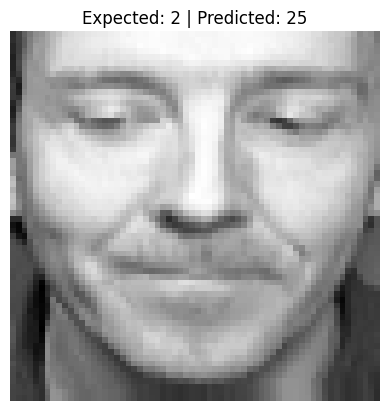

Cluster 0: activation=0.9995
Cluster 1: activation=0.9997
Cluster 2: activation=0.9998
Cluster 3: activation=0.9995
Cluster 4: activation=0.9996
Cluster 5: activation=0.9995
Cluster 6: activation=0.9993
Cluster 7: activation=0.9994
Cluster 8: activation=0.9997
Cluster 9: activation=0.9996
Cluster 10: activation=0.9995
Cluster 11: activation=0.9994
Cluster 12: activation=0.9995
Cluster 13: activation=0.9995
Cluster 14: activation=0.9995
Cluster 15: activation=0.9995
Cluster 16: activation=0.9994
Cluster 17: activation=0.9996
Cluster 18: activation=0.9996
Cluster 19: activation=0.9996
Cluster 20: activation=0.9997
Cluster 21: activation=0.9995
Cluster 22: activation=0.9995
Cluster 23: activation=0.9995
Cluster 24: activation=0.9994
Cluster 25: activation=0.9995
Cluster 26: activation=0.9995
Cluster 27: activation=0.9994
Cluster 28: activation=0.9994
Cluster 29: activation=0.9993
Cluster 30: activation=0.9994
Cluster 31: activation=0.9992
Cluster 32: activation=0.9994
Cluster 33: activati

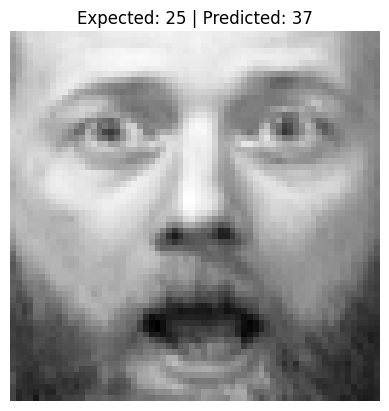

Cluster 0: activation=0.9994
Cluster 1: activation=0.9996
Cluster 2: activation=0.9997
Cluster 3: activation=0.9996
Cluster 4: activation=0.9995
Cluster 5: activation=0.9993
Cluster 6: activation=0.9992
Cluster 7: activation=0.9994
Cluster 8: activation=0.9996
Cluster 9: activation=0.9994
Cluster 10: activation=0.9997
Cluster 11: activation=0.9992
Cluster 12: activation=0.9999
Cluster 13: activation=0.9993
Cluster 14: activation=0.9995
Cluster 15: activation=0.9992
Cluster 16: activation=0.9994
Cluster 17: activation=0.9994
Cluster 18: activation=0.9993
Cluster 19: activation=0.9992
Cluster 20: activation=0.9996
Cluster 21: activation=0.9994
Cluster 22: activation=0.9992
Cluster 23: activation=0.9995
Cluster 24: activation=0.9993
Cluster 25: activation=0.9994
Cluster 26: activation=0.9996
Cluster 27: activation=0.9994
Cluster 28: activation=0.9991
Cluster 29: activation=0.9994
Cluster 30: activation=0.9995
Cluster 31: activation=0.9992
Cluster 32: activation=0.9993
Cluster 33: activati

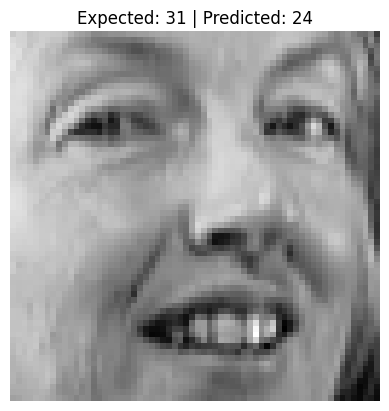

Cluster 0: activation=0.9996
Cluster 1: activation=0.9998
Cluster 2: activation=0.9997
Cluster 3: activation=0.9994
Cluster 4: activation=0.9996
Cluster 5: activation=0.9994
Cluster 6: activation=0.9995
Cluster 7: activation=0.9993
Cluster 8: activation=0.9997
Cluster 9: activation=0.9996
Cluster 10: activation=0.9995
Cluster 11: activation=0.9994
Cluster 12: activation=0.9995
Cluster 13: activation=0.9994
Cluster 14: activation=0.9996
Cluster 15: activation=0.9994
Cluster 16: activation=0.9996
Cluster 17: activation=0.9994
Cluster 18: activation=0.9995
Cluster 19: activation=0.9994
Cluster 20: activation=0.9996
Cluster 21: activation=0.9995
Cluster 22: activation=0.9994
Cluster 23: activation=0.9994
Cluster 24: activation=0.9995
Cluster 25: activation=0.9995
Cluster 26: activation=0.9994
Cluster 27: activation=0.9995
Cluster 28: activation=0.9993
Cluster 29: activation=0.9995
Cluster 30: activation=0.9994
Cluster 31: activation=0.9994
Cluster 32: activation=0.9995
Cluster 33: activati

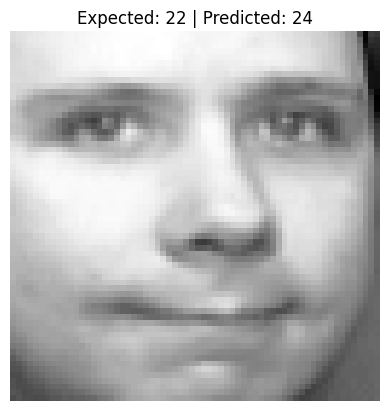

Cluster 0: activation=0.9997
Cluster 1: activation=0.9998
Cluster 2: activation=0.9997
Cluster 3: activation=0.9994
Cluster 4: activation=0.9996
Cluster 5: activation=0.9994
Cluster 6: activation=0.9994
Cluster 7: activation=0.9993
Cluster 8: activation=0.9997
Cluster 9: activation=0.9997
Cluster 10: activation=0.9995
Cluster 11: activation=0.9994
Cluster 12: activation=0.9996
Cluster 13: activation=0.9995
Cluster 14: activation=0.9994
Cluster 15: activation=0.9994
Cluster 16: activation=0.9996
Cluster 17: activation=0.9995
Cluster 18: activation=0.9994
Cluster 19: activation=0.9993
Cluster 20: activation=0.9997
Cluster 21: activation=0.9996
Cluster 22: activation=0.9994
Cluster 23: activation=0.9995
Cluster 24: activation=0.9995
Cluster 25: activation=0.9994
Cluster 26: activation=0.9994
Cluster 27: activation=0.9995
Cluster 28: activation=0.9993
Cluster 29: activation=0.9996
Cluster 30: activation=0.9995
Cluster 31: activation=0.9994
Cluster 32: activation=0.9996
Cluster 33: activati

In [12]:
def predict(net, cluster_label_map, X):
    cluster_id = net.predict(X)
    if cluster_id == -1:
        return None  # no matching cluster found
    return cluster_label_map[cluster_id]


def display_image_and_prediction(image, expected, predicted):
    plt.imshow(image.reshape(64, 64), cmap="gray")
    plt.title(f"Expected: {expected} | Predicted: {predicted}")
    plt.axis("off")
    plt.show()


accuracy_count = 0
number_to_test = min(10000, len(X_test))
mismatch_count = 0

for i, X in enumerate(X_test[:number_to_test]):
    predicted_digit = predict(net, cluster_label_map, X)
    actual_digit = y_test[i]

    if predicted_digit == actual_digit:
        accuracy_count += 1

    if predicted_digit != actual_digit:
        if mismatch_count >= 10:
            continue
        mismatch_count += 1
        print(f"Mismatch at sample {i}: expected {actual_digit}, predicted {predicted_digit}")
        display_image_and_prediction(X, actual_digit, predicted_digit)

print(f"Correct predictions: {accuracy_count} out of {number_to_test}")
print(f"Accuracy: {accuracy_count / number_to_test * 100:.2f}%")